## 2. Serve ML models

Read the [mpg dataset from kaggle](https://www.kaggle.com/datasets/uciml/autompg-dataset/code). In this exercise you'll need to develop a ML model to predict miles per gallon (mpg) for this dataset.





In [2]:
import pandas as pd

df = pd.read_csv("auto-mpg.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


a) Do EDA on the dataset

In [3]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [28]:
df = df[df["horsepower"] != "?"]
df["horsepower"] = df["horsepower"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


b) Go through data science workflow and try out different models until you find one you want to choose.



In [29]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns=["car name", "mpg"]), df["mpg"]
X.shape, y.shape

((392, 7), (392,))

In [30]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130,3504,12.0,70,1
1,8,350.0,165,3693,11.5,70,1
2,8,318.0,150,3436,11.0,70,1
3,8,304.0,150,3433,12.0,70,1
4,8,302.0,140,3449,10.5,70,1


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.11, random_state=42)
X_train.shape, X_val.shape, X_test.shape

((313, 7), (39, 7), (40, 7))

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_val = scaler.transform(X_val)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.max()=:.3f}")
print(f"{scaled_X_train.min()=:.3f}")
print(f"{scaled_X_train.std()=:.3f}\n")
print(f"{scaled_X_test.max()=:.3f}")
print(f"{scaled_X_test.min()=:.3f}")
print(f"{scaled_X_test.std()=:.3f}\n")
print(f"{scaled_X_val.max()=:.3f}")
print(f"{scaled_X_val.min()=:.3f}")
print(f"{scaled_X_val.std()=:.3f}")

scaled_X_train.max()=1.000
scaled_X_train.min()=0.000
scaled_X_train.std()=0.298

scaled_X_test.max()=1.000
scaled_X_test.min()=-0.011
scaled_X_test.std()=0.302

scaled_X_val.max()=1.000
scaled_X_val.min()=-0.011
scaled_X_val.std()=0.295


2

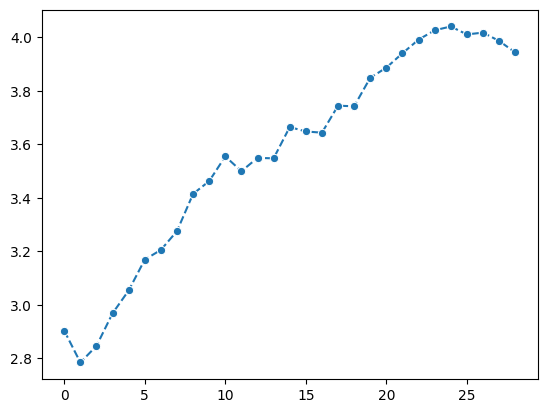

In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

error_list = []
for k in range(1,30):
    test_model = KNeighborsRegressor(n_neighbors=k)
    test_model.fit(scaled_X_train, y_train)
    y_pred = test_model.predict(scaled_X_val)
    error = root_mean_squared_error(y_val, y_pred)
    error_list.append(error)

sns.lineplot(error_list, marker="o", linestyle="--")

best_index = min(error_list)
best_k = error_list.index(best_index)+1
best_k

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

result = []
models = {
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(n_neighbors=best_k),
    "LinearRegression": LinearRegression(),
    "XGBoost": XGBRegressor() 
}

for key, model in models.items():
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = root_mean_squared_error(y_val, y_pred)
    
    result.append({
        "model": key,
        "mae": mae,
        "mse": mse,
        "rmse": rmse
    })
    
    

In [40]:
df = pd.DataFrame(result)
df

,model,mae,mse,rmse
0,RandomForest,2.178205,7.559907,2.749528
1,KNN,2.156410,7.753333,2.784481
2,LinearRegression,2.442334,12.326448,3.510904
3,XGBoost,2.331877,8.911511,2.985215



c) Train on all data in the dataset with your chosen model



In [41]:
# chosen model = RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

final_model = RandomForestRegressor()
final_model.fit(X_train,y_train)
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"{mae=}")
print(f"{mse=}")
print(f"{rmse=}")

mae=1.6930000000000003
mse=5.527429253164553
rmse=2.35104854334498


d) Now export the model with joblib



e) Read this model and create an API around it. You should have endpoints to be able to read the data, do some filterings and be able to send in data to get prediction back.